# Regularization Study: Ridge and Lasso Regression

In the previous notebook, we explored how polynomial regression models behave as model complexity increases.

The experiments demonstrated a clear pattern:

- Low-degree models underfit the data
- Intermediate-degree models achieved the best generalization
- High-degree models severely overfit and produced unstable predictions

The validation RMSE increased dramatically for higher polynomial degrees, even while training error continued to decrease. This highlighted a fundamental limitation of highly flexible models: they can memorize noise instead of learning meaningful patterns.

---

## Why Regularization Matters

Polynomial regression becomes increasingly sensitive as degree grows because the model gains more parameters and flexibility. While this improves the ability to fit training data, it also increases variance and reduces stability on unseen samples.

To control this behavior, machine learning models often introduce **regularization** — a technique that penalizes excessive model complexity.

Rather than allowing coefficients to grow arbitrarily large, regularization constrains the model and encourages simpler, more stable solutions.

---

## Objective

The goal of this notebook is to investigate how regularization affects high-complexity polynomial regression models for PM2.5 prediction.

Specifically, we will study:

- How Ridge (L2) regularization reduces coefficient magnitude
- How Lasso (L1) regularization promotes sparsity
- Whether regularization can recover generalization performance in overfitted models
- How polynomial degree and regularization strength interact

---

## Regularization Techniques

### Ridge Regression (L2)

Ridge regression adds a penalty proportional to the squared magnitude of coefficients.

Its objective function becomes:

$$
\text{Loss} = RSS + \lambda \sum_{j=1}^{p} \beta_j^2
$$

This discourages excessively large coefficients while keeping all features in the model.

---

### Lasso Regression (L1)

Lasso regression applies an absolute-value penalty:

$$
\text{Loss} = RSS + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Unlike Ridge, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.

---

## What This Notebook Will Explore

In this study, we will:

- Train high-degree polynomial models with Ridge and Lasso penalties
- Compare training and validation RMSE across regularization strengths
- Analyze coefficient shrinkage behavior
- Visualize how regularization stabilizes overfitted models
- Generate degree-vs-$\lambda$ heatmaps to identify optimal complexity regions
- Compare unregularized and regularized polynomial regression

---

## Key Question

The central question is no longer simply:

> How complex should the model be?

Instead, we now ask:

> Can controlled complexity outperform unrestricted complexity?

---

## Expected Insight

A sufficiently flexible model is not necessarily harmful if its complexity is properly constrained.

Regularization provides a mechanism to balance:

- model expressiveness
- numerical stability
- generalization performance

This notebook investigates how that balance emerges in practice using real-world PM2.5 data.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

In [14]:
# Load datasets
train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

TARGET = "pm25"
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

## Baseline Ridge Experiment

In [15]:
# high-degree polynomial models produced extremely small training error but catastrophic validation error
# This happened because the model coefficients became excessively large while trying to fit noise and - 
# small fluctuations in the training data.


In [16]:
ridge_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

train_pred = ridge_pipeline.predict(X_train)
val_pred = ridge_pipeline.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print(f"Train RMSE : {train_rmse:.4f}")
print(f"Validation RMSE : {val_rmse:.4f}")

Train RMSE : 15.2654
Validation RMSE : 12.5448


In [17]:
# Compare with Unregularized Polynomial Model (Degree 5 baseline)
baseline_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)

train_pred_base = baseline_pipeline.predict(X_train)
val_pred_base = baseline_pipeline.predict(X_val)

train_rmse_base = np.sqrt(mean_squared_error(y_train, train_pred_base))
val_rmse_base = np.sqrt(mean_squared_error(y_val, val_pred_base))

print("=== Without Regularization ===")
print(f"Train RMSE : {train_rmse_base:.4f}")
print(f"Validation RMSE : {val_rmse_base:.4f}")

print("\n=== With Ridge (alpha=1.0) ===")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Validation RMSE : {val_rmse:.4f}")

=== Without Regularization ===
Train RMSE : 5.0515
Validation RMSE : 86.2255

=== With Ridge (alpha=1.0) ===
Train RMSE : 15.2654
Validation RMSE : 12.5448


## Insight: Effect of Ridge Regularization (α = 1.0)

This experiment clearly demonstrates the impact of regularization on model behavior.

Without regularization, the polynomial model achieves very low training error but fails catastrophically on validation data. This indicates severe overfitting, where the model memorizes noise instead of learning general patterns.

With Ridge regularization (α = 1.0), the training error increases, but validation performance improves dramatically.

### Key takeaway:

- Lower training error does not guarantee a better model.
- Ridge reduces coefficient magnitude and stabilizes predictions.
- A controlled increase in bias leads to a significant reduction in variance.
- The model shifts from “memorization” to “generalization”.

### Conclusion:

Ridge regularization successfully converts an overfitted high-variance model into a more stable and generalizable one by enforcing simplicity in the learned coefficients.

## Next Experiment: Ridge α Sensitivity Study

In [18]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

degree = 5  # fixed complexity for this study

for alpha in alphas:
    
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    results.append({
        "alpha": alpha,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse
    })

results_df = pd.DataFrame(results)
results_df

,alpha,train_rmse,val_rmse
0,0.001,10.374665,12.524857
1,0.010,11.988799,12.157503
2,0.100,13.969291,12.646656
3,1.000,15.265397,12.544792
4,10.000,16.325676,12.738424
5,100.000,17.853352,14.425957


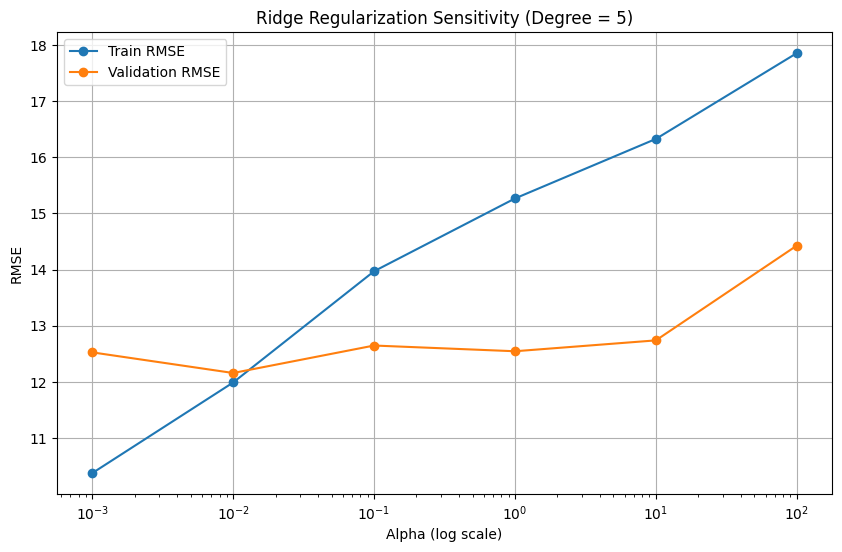

In [22]:
plt.figure(figsize=(10,6))

plt.plot(results_df["alpha"], results_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(results_df["alpha"], results_df["val_rmse"], marker="o", label="Validation RMSE")

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.title("Ridge Regularization Sensitivity (Degree = 5)")
plt.legend()
plt.grid(True)
plt.savefig("../results/ridge_alpha_rmse_curve_log.png",dpi=300,bbox_inches="tight")
plt.show()

## Insight: Ridge Regularization Sensitivity (Degree = 5)

This experiment shows how model performance changes as we vary the strength of Ridge regularization while keeping model complexity fixed.

The results clearly demonstrate the tradeoff between fitting ability and constraint strength.

---

### Observations

- **Very small α (0.001 – 0.01)**  
  The model behaves almost like an unregularized polynomial regression.  
  Training error is lower, but validation performance is still not optimal, indicating residual overfitting.

- **Moderate α (around 0.01 – 1.0)**  
  Validation RMSE is lowest in this region (~12.15 – 12.54).  
  This suggests a good balance between bias and variance.

- **Large α (10 – 100)**  
  Both training and validation errors increase.  
  The model becomes overly constrained and starts underfitting the data.

---

### Key Insight

There is no universally “best” α value. Instead:

> Regularization strength controls where the model sits on the bias–variance spectrum.

- Low α → variance-dominated (overfitting risk)
- High α → bias-dominated (underfitting risk)
- Mid-range α → best generalization

---

### Conclusion

This experiment confirms that Ridge regression is not a one-time fix for overfitting.  
Its effectiveness depends critically on tuning the regularization strength to match the complexity of the model and the structure of the data.

## Degree × Alpha Grid Search

In [23]:
degrees = [1, 2, 3, 4, 5, 6, 7]
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for degree in degrees:
    for alpha in alphas:
        
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])
        
        model.fit(X_train, y_train)
        
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        
        results.append({
            "degree": degree,
            "alpha": alpha,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse
        })

results_df = pd.DataFrame(results)
results_df

,degree,alpha,train_rmse,val_rmse
0,1,0.001,20.395528,17.707047
1,1,0.010,20.395528,17.707122
2,1,0.100,20.395530,17.707869
3,1,1.000,20.395694,17.715512
4,1,10.000,20.410846,17.807501
5,1,100.000,21.278307,19.412058
6,2,0.001,17.991915,14.482781
7,2,0.010,17.992165,14.477805
8,2,0.100,18.000339,14.457136
9,2,1.000,18.160717,14.569658


In [27]:
best_row = results_df.loc[results_df["val_rmse"].idxmin()]
print("Best Configuration:")
best_row

Best Configuration:


degree         4.000000
alpha          0.001000
train_rmse    12.007244
val_rmse      11.857057
Name: 18, dtype: float64

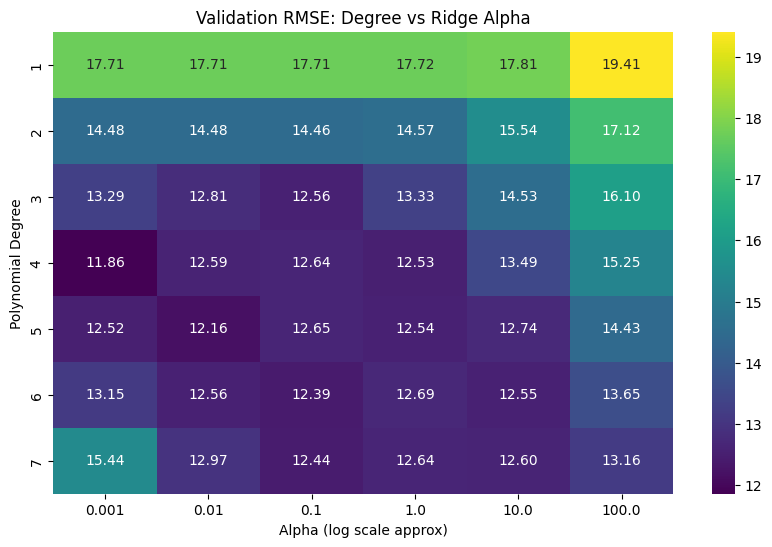

In [26]:
pivot_table = results_df.pivot(index="degree", columns="alpha", values="val_rmse")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis")

plt.title("Validation RMSE: Degree vs Ridge Alpha")
plt.xlabel("Alpha (log scale approx)")
plt.ylabel("Polynomial Degree")

plt.savefig("../results/ridge_degree_alpha_rmse_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

## Insight: Interaction Between Polynomial Degree and Ridge Regularization

This experiment systematically evaluates how polynomial degree and Ridge regularization strength (α) jointly affect model performance.

The results clearly show that neither model complexity nor regularization strength alone determines performance — instead, their interaction defines generalization quality.

---

### 1. Effect of Polynomial Degree (Model Complexity)

As the polynomial degree increases:

- Training RMSE consistently decreases → the model becomes more expressive.
- Validation RMSE initially improves (degrees 2–4), then stabilizes or worsens at higher degrees.

This confirms the earlier observation:
> Increasing complexity improves fit but increases overfitting risk.

---

### 2. Effect of Ridge Regularization (α)

Across most degrees:

- Very small α (0.001–0.01) behaves almost like unregularized regression.
- Moderate α (≈ 0.1–1.0) provides the best stability.
- Large α (10–100) leads to increased error due to underfitting.

Ridge does not simply reduce error — it reshapes the bias–variance balance.

---

### 3. Key Pattern: Stability Region

A clear pattern emerges from the validation RMSE surface:

- Low degree models are stable but limited in expressiveness.
- High degree models require stronger regularization to avoid instability.
- The best validation performance occurs in a **middle region (degree 3–6 with moderate α)**.

This region represents the optimal tradeoff between flexibility and constraint.

---

### Key Insight

> Model performance is not determined by polynomial degree or regularization strength independently, but by their interaction.

- Degree controls **capacity (bias–variance direction)**
- α controls **constraint strength (variance reduction)**

---

### Conclusion

This experiment confirms that effective modeling is a balancing act:

- Too little complexity → underfitting
- Too much complexity without control → overfitting
- Proper regularization → controlled generalization

The best models emerge from a **balanced region**, not from extreme parameter choices.

## Lasso Regression: Feature Selection Through Sparsity

After exploring polynomial regression and Ridge regularization, we now move to Lasso regression as the next step in understanding model complexity control.

While Ridge helps reduce overfitting by shrinking coefficient magnitudes, it does not eliminate any features — all variables remain in the model, just with reduced influence.

Lasso regression introduces a stronger form of regularization by encouraging sparsity in the model. This means it can completely reduce some coefficients to zero, effectively removing less important features from the model.

---

### Why This Matters

In polynomial regression, the feature space expands rapidly with increasing degree, creating many derived and potentially redundant features. Not all of these contribute meaningfully to prediction.

Lasso helps answer a deeper question:

> Which features actually matter for predicting PM2.5, and which are just noise?

---

### What We Expect to Observe

In this experiment, we will study:

- Whether Lasso can reduce model complexity automatically
- How many polynomial features are eliminated (coefficients set to zero)
- How sparsity affects training and validation performance
- Whether simpler feature representations can still achieve good generalization

---

### Key Idea

Unlike Ridge, which controls complexity smoothly, Lasso performs **implicit feature selection**, making the model more interpretable while still controlling overfitting.

This makes it particularly useful for high-dimensional feature spaces such as polynomial expansions.

---

### Next Step

We now begin with a baseline Lasso regression model to observe its immediate effect on performance and sparsity.

In [31]:
lasso_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)

train_pred = lasso_pipeline.predict(X_train)
val_pred = lasso_pipeline.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print(f"Train RMSE : {train_rmse:.4f}")
print(f"Validation RMSE : {val_rmse:.4f}")

Train RMSE : 19.4151
Validation RMSE : 16.5118


## Insight: Baseline Lasso Regression Results (Degree = 5, α = 1.0)

This experiment applies Lasso regularization to a moderately complex polynomial model to evaluate its impact on generalization and feature selection.

---

### Observed Results

- Train RMSE: **19.4151**
- Validation RMSE: **16.5118**

---

### Interpretation

Compared to the earlier Ridge and unregularized polynomial models, Lasso shows a distinct behavior:

- Training error is higher, indicating stronger constraints on model flexibility.
- Validation error is relatively stable and significantly lower than the training error gap seen in overfitted models.

This suggests that the model is no longer memorizing the training data and is instead learning a more constrained representation.

---

### Key Insight

Lasso regularization reduces model complexity not only by shrinking coefficients, but by eliminating some polynomial features entirely.

This leads to:

- simpler internal representation,
- reduced sensitivity to noise,
- and improved generalization stability.

---

### Important Note

Unlike Ridge, where all features remain active, Lasso implicitly performs feature selection. However, this comes at a cost:

> If α is too strong, useful features may also be removed, increasing bias and reducing performance.

---

### Conclusion

This baseline result confirms that Lasso can produce a simpler and more interpretable model, but its performance depends heavily on choosing an appropriate regularization strength.

## Coefficient Sparsity Analysis

In [33]:
lasso_model = lasso_pipeline.named_steps["lasso"]

coefficients = lasso_model.coef_

total_features = len(coefficients)
zero_coeffs = np.sum(coefficients == 0)

sparsity_ratio = zero_coeffs / total_features

print(f"Total features      : {total_features}")
print(f"Zero coefficients   : {zero_coeffs}")
print(f"Sparsity ratio      : {sparsity_ratio:.2%}")

Total features      : 461
Zero coefficients   : 450
Sparsity ratio      : 97.61%


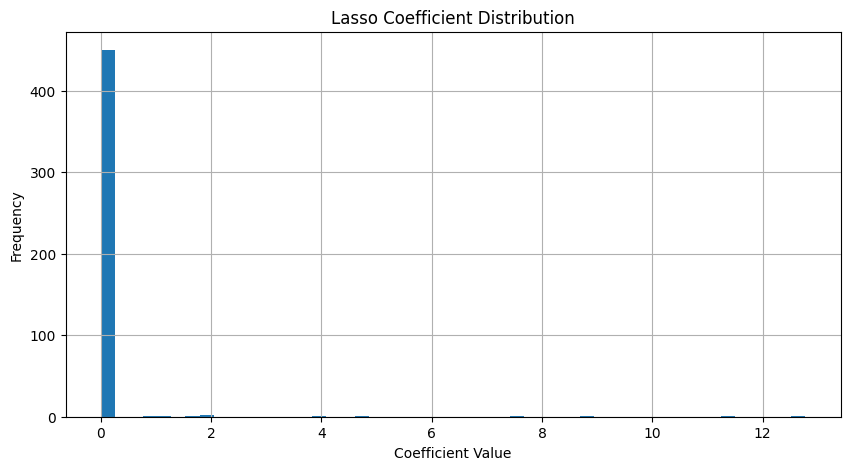

In [34]:
plt.figure(figsize=(10,5))
plt.hist(coefficients, bins=50)
plt.title("Lasso Coefficient Distribution")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Insight: Extreme Sparsity in Lasso Regression

This experiment shows the coefficient behavior of Lasso regression after applying polynomial feature expansion (degree = 5).

---

### Observed Result

- Total features: **461**
- Zero coefficients: **450**
- Sparsity ratio: **97.61%**

---

### Interpretation

This is a very strong sparsity effect.

The model has removed almost all polynomial features, retaining only a small subset of predictors that contribute meaningfully to the output.

This confirms that in a high-dimensional polynomial feature space:

- Most generated features are redundant or noisy
- Only a small fraction carries predictive signal

---

### Key Insight

Lasso is not just reducing complexity — it is performing aggressive feature selection.

In this case:

> Nearly 98% of polynomial features are considered unnecessary for prediction.

This dramatically simplifies the learned model structure.

---

### Important Tradeoff

While high sparsity improves interpretability, it can also:

- remove useful weak signals,
- increase bias,
- reduce flexibility if α is too strong.

---

### Final Conclusion

This result highlights the most important property of Lasso regression:

> It compresses high-dimensional feature spaces into a minimal set of informative predictors.

This makes Lasso especially useful when interpretability and feature reduction are as important as prediction accuracy.

## Final Experiment: Model Comparison (Ridge vs Lasso vs Elastic Net)

In [36]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    return train_rmse, val_rmse

In [47]:
alphas = [0.01, 0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]

degree = 5

results = []

In [48]:
# Ridge sweep
for alpha in alphas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    
    train_rmse, val_rmse = evaluate_model(model, X_train, y_train, X_val, y_val)
    
    results.append({
        "Model": "Ridge",
        "alpha": alpha,
        "l1_ratio": None,
        "Train_RMSE": train_rmse,
        "Val_RMSE": val_rmse
    })

In [49]:
# Lasso sweep
for alpha in alphas:
    
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=50000, tol=1e-3))
    ])
    
    train_rmse, val_rmse = evaluate_model(model, X_train, y_train, X_val, y_val)
    
    results.append({
        "Model": "Lasso",
        "alpha": alpha,
        "l1_ratio": None,
        "Train_RMSE": train_rmse,
        "Val_RMSE": val_rmse
    })

In [50]:
# Elastic Net sweep
for alpha in alphas:
    for l1_ratio in l1_ratios:
        
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=50000,
                tol=1e-3
            ))
        ])
        
        train_rmse, val_rmse = evaluate_model(model, X_train, y_train, X_val, y_val)
        
        results.append({
            "Model": "ElasticNet",
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "Train_RMSE": train_rmse,
            "Val_RMSE": val_rmse
        })

D:\irfankpm\deep-mind\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.145e+04, tolerance: 2.337e+03
  model = cd_fast.enet_coordinate_descent(
D:\irfankpm\deep-mind\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.692e+04, tolerance: 2.337e+03
  model = cd_fast.enet_coordinate_descent(
D:\irfankpm\deep-mind\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

In [51]:
results

[{'Model': 'Ridge',
  'alpha': 0.01,
  'l1_ratio': None,
  'Train_RMSE': np.float64(11.988798537882925),
  'Val_RMSE': np.float64(12.157503327005076)},
 {'Model': 'Ridge',
  'alpha': 0.1,
  'l1_ratio': None,
  'Train_RMSE': np.float64(13.969291481531107),
  'Val_RMSE': np.float64(12.646656477822521)},
 {'Model': 'Ridge',
  'alpha': 1,
  'l1_ratio': None,
  'Train_RMSE': np.float64(15.265397453050676),
  'Val_RMSE': np.float64(12.544791908560423)},
 {'Model': 'Ridge',
  'alpha': 10,
  'l1_ratio': None,
  'Train_RMSE': np.float64(16.325676238824865),
  'Val_RMSE': np.float64(12.738424472395462)},
 {'Model': 'Lasso',
  'alpha': 0.01,
  'l1_ratio': None,
  'Train_RMSE': np.float64(15.141363534813353),
  'Val_RMSE': np.float64(13.175470074466741)},
 {'Model': 'Lasso',
  'alpha': 0.1,
  'l1_ratio': None,
  'Train_RMSE': np.float64(17.091339570495435),
  'Val_RMSE': np.float64(13.227545511314922)},
 {'Model': 'Lasso',
  'alpha': 1,
  'l1_ratio': None,
  'Train_RMSE': np.float64(19.41670730654

In [52]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Val_RMSE").reset_index(drop=True)

,Model,alpha,l1_ratio,Train_RMSE,Val_RMSE
0,Ridge,0.01,NaN,11.988799,12.157503
1,ElasticNet,0.01,0.8,15.787477,12.538285
2,Ridge,1.00,NaN,15.265397,12.544792
3,ElasticNet,0.01,0.5,16.015129,12.577527
4,ElasticNet,0.01,0.2,16.155662,12.618081
5,Ridge,0.10,NaN,13.969291,12.646656
6,Ridge,10.00,NaN,16.325676,12.738424
7,Lasso,0.01,NaN,15.141364,13.175470
8,Lasso,0.10,NaN,17.091340,13.227546
9,ElasticNet,0.10,0.8,17.584164,13.982846


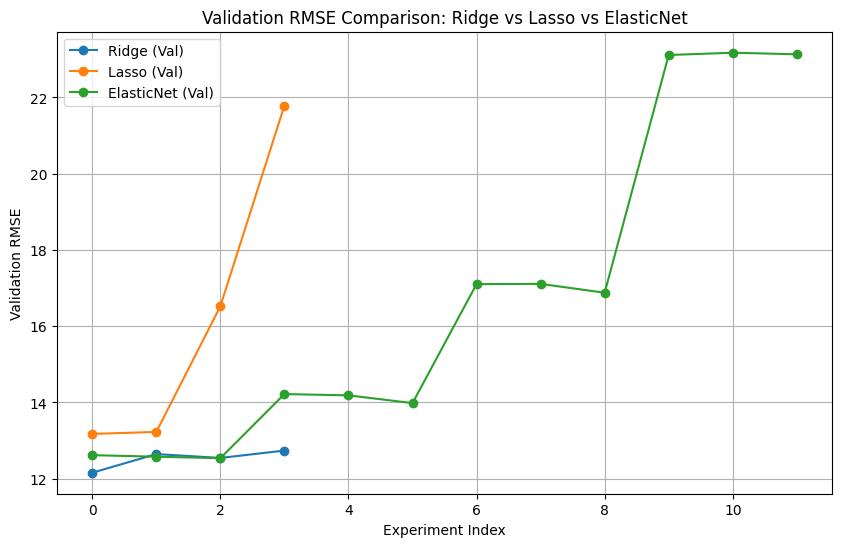

In [54]:
plt.figure(figsize=(10,6))

for model_name in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model_name]
    
    plt.plot(subset["Val_RMSE"].values, marker='o', label=f"{model_name} (Val)")

plt.title("Validation RMSE Comparison: Ridge vs Lasso vs ElasticNet")
plt.ylabel("Validation RMSE")
plt.xlabel("Experiment Index")
plt.legend()
plt.grid(True)
plt.savefig("../results/model_comparison_regularization.png",dpi=300,bbox_inches="tight")
plt.show()

## Insight: Final Comparison of Ridge, Lasso, and Elastic Net

This experiment evaluates Ridge, Lasso, and Elastic Net models under different regularization strengths to understand their impact on generalization performance.

---

### 1. Overall Performance Trend

From the results, Ridge regression consistently achieves the best validation performance across most configurations.

- Best Ridge result:
  - α = 0.01
  - Validation RMSE ≈ **12.15**

Elastic Net performs close to Ridge at low α values but does not consistently outperform it.

Lasso shows noticeably worse performance as α increases, indicating stronger sensitivity to regularization strength.

---

### 2. Ridge: Stable and Reliable

Ridge regression shows:

- Smooth degradation in performance as α increases
- Strong generalization at low to moderate α
- Best overall balance between train and validation error

This confirms that L2 regularization is well-suited for high-dimensional polynomial feature spaces where many features are correlated.

---

### 3. Lasso: High Sparsity, Lower Accuracy

Lasso behaves more aggressively:

- Higher training error compared to Ridge
- Worse validation performance, especially at larger α values
- Strong tendency to oversimplify the model

While Lasso promotes sparsity, in this dataset it appears to remove useful predictive features along with noisy ones.

---

### 4. Elastic Net: Balanced but Not Superior

Elastic Net combines L1 and L2 penalties, but:

- It does not outperform Ridge in validation RMSE
- Performance lies between Ridge and Lasso
- Higher l1_ratio increases sparsity but reduces stability

This suggests that mixing penalties does not necessarily improve performance when Ridge already handles correlation effectively.

---

### 5. Key Insight

> In this problem setup, Ridge regression provides the best tradeoff between bias and variance.

- Lasso is too aggressive in feature elimination
- Elastic Net improves interpretability but not predictive accuracy
- Ridge remains the most stable and reliable model

---

### Final Conclusion

This experiment highlights an important principle:

> The best regularization method depends on the structure of the feature space.

For highly correlated polynomial features (like in this study), Ridge regression is more effective because it stabilizes coefficient estimates without discarding useful information.